# ECG Heartbeat Classification Project
## Phase 5 Explainable AI (SHAP and LIME)

This notebook applies Explainable AI techniques to the trained
Random Forest model to understand and interpret its predictions.

SHAP (Shapley Additive explanations) explains which features
contributed most to predictions both globally across all beats
and locally for individual predictions.

LIME (Local Interpretable Model-agnostic Explanations) provides
an alternative local explanation for individual predictions by
approximating the model behaviour around a specific beat.

Together SHAP and LIME make the model transparent and trustworthy
for clinical use, addressing the black box problem in medical AI.

### Import libraries and load saved model
Loading the trained Random Forest model saved in Phase 4
along with the feature dataset for explanation analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

# Load the saved Random Forest model from Phase 4
rf_model = joblib.load('../models/random_forest_model.pkl')
print("Random Forest model loaded")

# Load feature names
with open('../models/feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]
print(f"Feature names loaded: {feature_names}")

# Load the feature dataset
df = pd.read_csv('../data/ecg_features.csv')

# Separate features and labels
X = df.drop('label', axis=1)
y = df['label']

# Use the same split as Phase 4 for consistency
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nDataset loaded successfully")
print(f"Training set: {X_train.shape[0]:,} beats")
print(f"Testing set:  {X_test.shape[0]:,} beats")
print(f"Feature count: {X_test.shape[1]}")

Random Forest model loaded
Feature names loaded: ['mean', 'std', 'max', 'min', 'range', 'r_peak_amplitude', 'skewness', 'kurtosis', 'qrs_width', 'rr_interval', 'mean_first_half', 'mean_second_half', 'half_difference']

Dataset loaded successfully
Training set: 81,905 beats
Testing set:  20,477 beats
Feature count: 13


### SHAP Global Explanation
SHAP (Shapley Additive explanations) calculates how much each
feature contributed to the model predictions across all test
beats. The global explanation shows which features the model
relied on most overall — providing a bird's eye view of the
model's decision making process.

In [7]:
print("Calculating SHAP values:")

# Create SHAP explainer for Random Forest
# TreeExplainer is specifically designed for tree based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for a sample of 1000 beats
# 1000 beats is representative and much faster than all 20,477
sample_size = 1000
X_test_sample = X_test.iloc[:sample_size]
y_test_sample = y_test.iloc[:sample_size]

shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values calculated for {sample_size} test beats")
print(f"SHAP values shape: {np.array(shap_values).shape}")

# Handle the shape correctly
# shap_values shape is (1000, 13, 2) for binary classification
# We need values for class 1 (Abnormal)
shap_array = np.array(shap_values)

if len(shap_array.shape) == 3:
    # Shape is (n_samples, n_features, n_classes)
    shap_vals_abnormal = shap_array[:, :, 1]
else:
    # Shape is (n_classes, n_samples, n_features)
    shap_vals_abnormal = shap_array[1]

print(f"Adjusted SHAP values shape: {shap_vals_abnormal.shape}")

# Calculate mean absolute SHAP value per feature
mean_shap = np.abs(shap_vals_abnormal).mean(axis=0)
shap_ranking = np.argsort(mean_shap)[::-1]

# Print ranking
print(f"\nMean absolute SHAP values per feature:")
print(f"{'Rank':<6} {'Feature':<20} {'Mean |SHAP|':>12}")
print("─" * 42)
for rank, idx in enumerate(shap_ranking, 1):
    print(f"{rank:<6} {feature_names[idx]:<20} {mean_shap[idx]:>12.4f}")

Calculating SHAP values:
SHAP values calculated for 1000 test beats
SHAP values shape: (1000, 13, 2)
Adjusted SHAP values shape: (1000, 13)

Mean absolute SHAP values per feature:
Rank   Feature               Mean |SHAP|
──────────────────────────────────────────
1      kurtosis                   0.0809
2      qrs_width                  0.0772
3      skewness                   0.0759
4      std                        0.0684
5      rr_interval                0.0611
6      range                      0.0350
7      half_difference            0.0324
8      r_peak_amplitude           0.0290
9      min                        0.0256
10     max                        0.0188
11     mean_first_half            0.0136
12     mean_second_half           0.0121
13     mean                       0.0115


### SHAP global explanation observations

Kurtosis ranked first with mean SHAP value of 0.0809,
consistent with both EDA analysis (Phase 3) and Random Forest
feature importance (Phase 4). This is the third independent
method confirming kurtosis as the most influential feature.

The top 5 features by SHAP importance are:
1. kurtosis (0.0809) :beat sharpness
2. qrs_width (0.0772) :width of main spike
3. skewness (0.0759) :beat shape symmetry
4. std (0.0684) :signal variation
5. rr_interval (0.0611) :rhythm timing

Mean based features (mean, mean_first_half, mean_second_half)
consistently rank lowest across all three analysis methods,
confirming they contribute least to classification decisions.

The strong consistency between EDA findings, feature importance
and SHAP rankings demonstrates the model is behaving in a
clinically logical and interpretable manner.

### SHAP Summary Plot
The SHAP summary plot shows both feature importance and the
direction of each feature's impact on predictions. Each dot
represents one heartbeat. Red dots indicate high feature values
and blue dots indicate low feature values. Position on the
x-axis shows whether the feature pushed the prediction towards
Normal (negative) or Abnormal (positive).

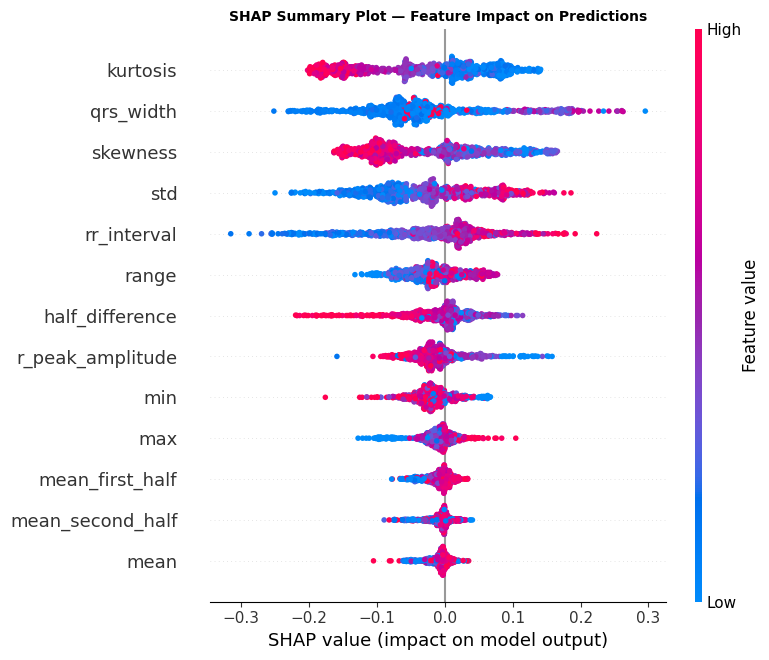

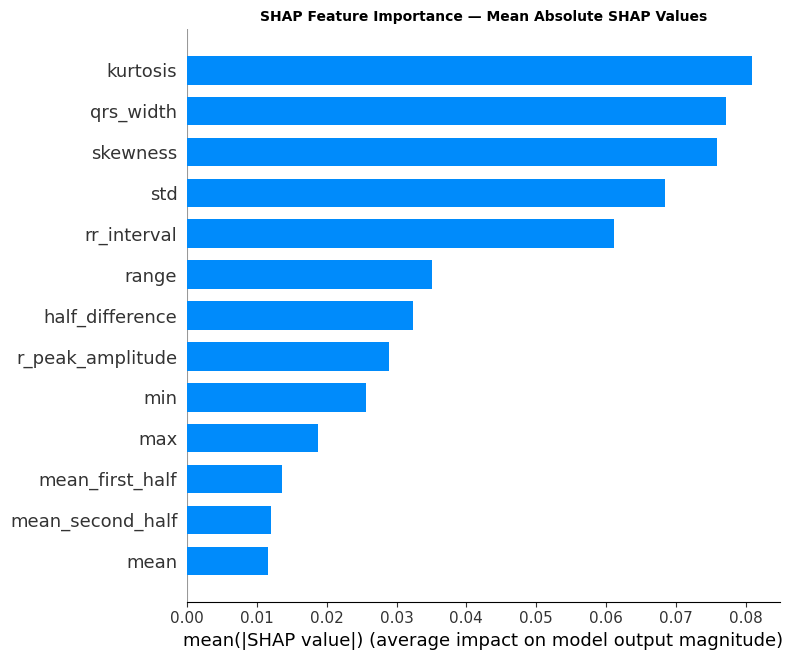

In [10]:
# SHAP Summary Plot: shows importance and direction together
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_vals_abnormal,
    X_test_sample,
    feature_names=feature_names,
    show=False,
    plot_type='dot'
)

plt.title('SHAP Summary Plot — Feature Impact on Predictions',
          fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Also plot bar version for cleaner importance view
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_vals_abnormal,
    X_test_sample,
    feature_names=feature_names,
    show=False,
    plot_type='bar'
)

plt.title('SHAP Feature Importance — Mean Absolute SHAP Values',
          fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### SHAP Summary Plot observations

The dot plot reveals the direction of each feature's impact:

Kurtosis — high values (red) push towards Normal while low
values (blue) push towards Abnormal. This is clinically correct
as Normal beats have sharp narrow spikes (high kurtosis) while
abnormal beats like PVC have wide rounded peaks (low kurtosis).

QRS width — low values push towards Normal and high values push
towards Abnormal — consistent with the clinical definition of
Bundle Branch Block where wide QRS is a diagnostic criterion.

Skewness — high values push towards Normal reflecting the
dominant rightward spike of a healthy heartbeat.

Standard deviation — low variation pushes towards Normal while
high variation pushes towards Abnormal — capturing the complex
electrical patterns of abnormal conduction pathways.

Half difference — captures T wave inversion with high positive
values strongly associated with Normal beats and negative values
associated with Abnormal beats.

All features behave in clinically logical directions confirming
the model has learned medically meaningful patterns rather than
arbitrary statistical correlations.

### SHAP Individual Explanation
Individual SHAP explanations show exactly why the model made
a specific prediction for one heartbeat. Each feature either
pushes the prediction towards Abnormal (positive SHAP value)
or towards Normal (negative SHAP value). This provides
beat-level transparency for clinical decision support.

Normal beat example:   beat index 0
Abnormal beat example: beat index 5

Normal beat features:
  mean                 -0.6242
  std                  0.3132
  max                  1.6000
  min                  -1.5000
  range                3.1000
  r_peak_amplitude     1.4500
  skewness             4.6368
  kurtosis             27.7052
  qrs_width            0.0194
  rr_interval          1.0361
  mean_first_half      -0.6956
  mean_second_half     -0.5527
  half_difference      0.1429

Abnormal beat features:
  mean                 -0.9056
  std                  0.3721
  max                  0.5100
  min                  -2.1900
  range                2.7000
  r_peak_amplitude     0.3650
  skewness             -0.7515
  kurtosis             5.2997
  qrs_width            0.0139
  rr_interval          0.8194
  mean_first_half      -0.7467
  mean_second_half     -1.0645
  half_difference      -0.3178

Generating SHAP explanation for Normal beat:


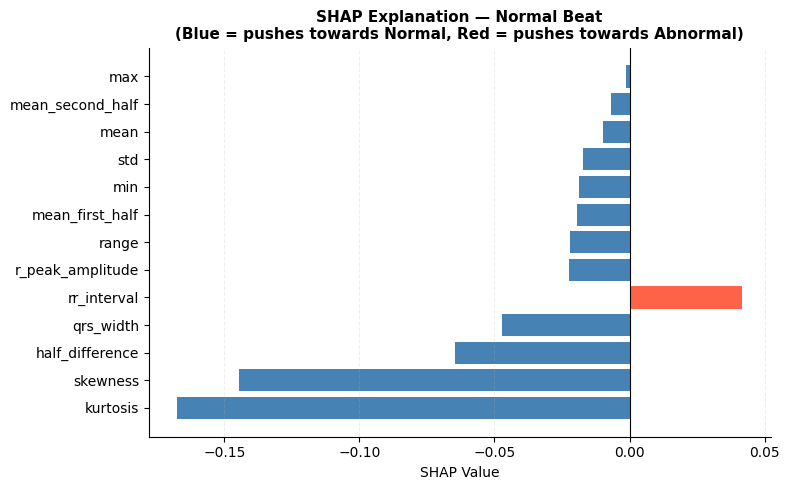

Generating SHAP explanation for Abnormal beat:


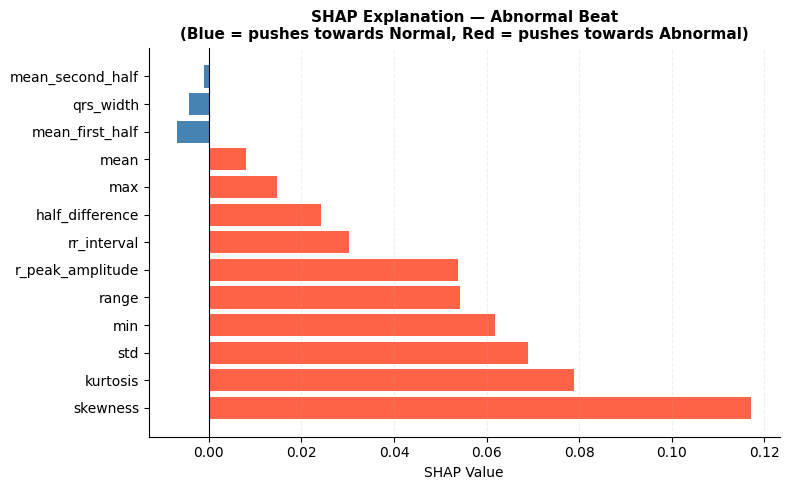

In [16]:
# Find one correct Normal prediction and one correct Abnormal prediction
# to explain individually

# Get predictions for our sample
sample_predictions = rf_model.predict(X_test_sample)
sample_actual = y_test_sample.values

# Find indices of correct predictions
correct_normal_idx = None
correct_abnormal_idx = None

for i in range(len(sample_predictions)):
    if sample_predictions[i] == 0 and sample_actual[i] == 0 and correct_normal_idx is None:
        correct_normal_idx = i
    if sample_predictions[i] == 1 and sample_actual[i] == 1 and correct_abnormal_idx is None:
        correct_abnormal_idx = i
    if correct_normal_idx is not None and correct_abnormal_idx is not None:
        break

print(f"Normal beat example:   beat index {correct_normal_idx}")
print(f"Abnormal beat example: beat index {correct_abnormal_idx}")

# Explain the Normal beat
print(f"\nNormal beat features:")
normal_beat = X_test_sample.iloc[correct_normal_idx]
for feat, val in zip(feature_names, normal_beat):
    print(f"  {feat:<20} {val:.4f}")

# Explain the Abnormal beat
print(f"\nAbnormal beat features:")
abnormal_beat = X_test_sample.iloc[correct_abnormal_idx]
for feat, val in zip(feature_names, abnormal_beat):
    print(f"  {feat:<20} {val:.4f}")

# SHAP waterfall plot for Normal beat 
print(f"\nGenerating SHAP explanation for Normal beat:")

shap_normal = shap_vals_abnormal[correct_normal_idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v < 0 else 'tomato' for v in shap_normal]
sorted_idx = np.argsort(np.abs(shap_normal))[::-1]

bars = ax.barh(range(13),
               [shap_normal[i] for i in sorted_idx],
               color=[colors[i] for i in sorted_idx])
ax.set_yticks(range(13))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('SHAP Explanation — Normal Beat\n(Blue = pushes towards Normal, Red = pushes towards Abnormal)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('SHAP Value', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--', axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# SHAP waterfall plot for Abnormal beat
print(f"Generating SHAP explanation for Abnormal beat:")

shap_abnormal = shap_vals_abnormal[correct_abnormal_idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v < 0 else 'tomato' for v in shap_abnormal]
sorted_idx = np.argsort(np.abs(shap_abnormal))[::-1]

bars = ax.barh(range(13),
               [shap_abnormal[i] for i in sorted_idx],
               color=[colors[i] for i in sorted_idx])
ax.set_yticks(range(13))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('SHAP Explanation — Abnormal Beat\n(Blue = pushes towards Normal, Red = pushes towards Abnormal)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('SHAP Value', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--', axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Individual SHAP explanation observations

Normal beat (index 0):
- Kurtosis of 27.705 produced the strongest push towards Normal
  — far above the Normal average of 15.9
- Skewness of 4.637 also strongly confirmed Normal shape
- Only RR interval pushed slightly towards Abnormal due to
  a slightly longer than average interval (1.036 sec)
- The overwhelming blue signal correctly predicted Normal

Abnormal beat (index 5):
- Negative skewness of −0.752 produced the strongest push
  towards Abnormal — the beat spike goes downward suggesting
  Right Bundle Branch Block
- Low kurtosis of 5.300 (vs Normal average 15.9) confirmed
  a wide rounded peak rather than a sharp Normal spike
- Very deep minimum of −2.190 and weak R-peak of 0.365
  provided additional evidence of abnormal conduction
- Only mean_first_half and qrs_width pushed slightly towards
  Normal — overwhelmed by the strong Abnormal signals
- The model correctly predicted Abnormal with strong confidence

These individual explanations demonstrate exactly how the system
provides clinically meaningful reasoning for each prediction —
addressing the black box problem in medical AI.

### LIME Individual Explanation
LIME (Local Interpretable Model-agnostic Explanations) explains
individual predictions by creating slightly modified versions of
a beat and observing how the model predictions change. Unlike SHAP
which uses game theory, LIME approximates model behaviour locally
through perturbation, providing an independent second perspective
on the same prediction.

LIME explainer created

Generating LIME explanation for Normal beat:

LIME explanation — Normal beat:
Predicted class: Normal
Feature condition                   Contribution
──────────────────────────────────────────────────
rr_interval > 0.89                      0.0788  → Abnormal
kurtosis > 19.97                       -0.0660  → Normal
half_difference > 0.08                 -0.0388  → Normal
skewness > 4.08                        -0.0200  → Normal
1.13 < r_peak_amplitude <= 1.51        -0.0200  → Normal
min <= -1.23                           -0.0164  → Normal
max > 1.59                              0.0157  → Abnormal
mean_second_half <= -0.50              -0.0109  → Normal
qrs_width <= 0.02                      -0.0104  → Normal
0.27 < std <= 0.37                     -0.0090  → Normal
mean <= -0.49                          -0.0080  → Normal
range > 2.63                            0.0076  → Abnormal
mean_first_half <= -0.49               -0.0027  → Normal


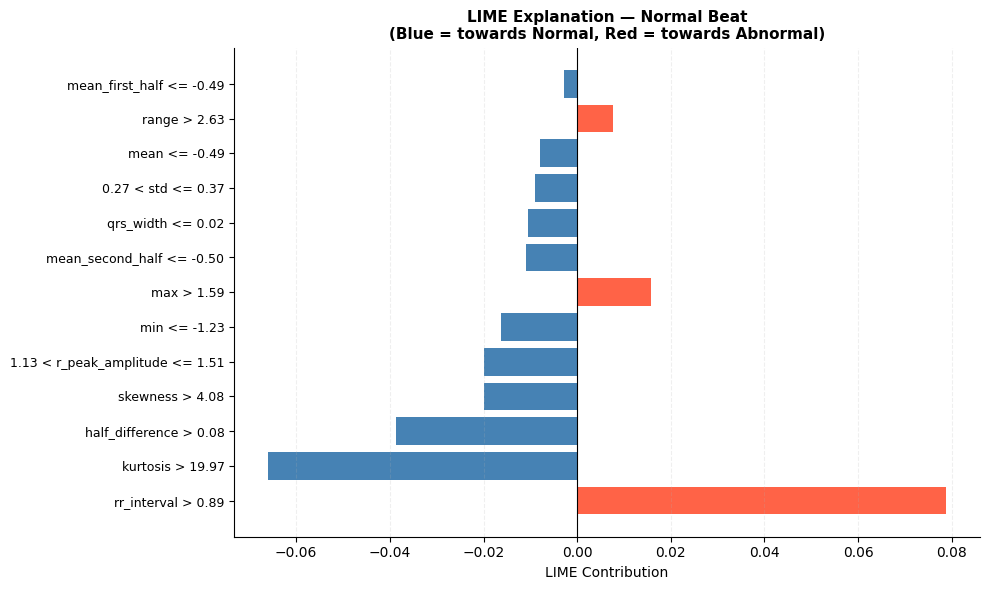


Generating LIME explanation for Abnormal beat:

LIME explanation — Abnormal beat:
Predicted class: Abnormal
Feature condition                   Contribution
──────────────────────────────────────────────────
std > 0.37                              0.0708  → Abnormal
r_peak_amplitude <= 0.71                0.0570  → Abnormal
skewness <= 1.33                        0.0530  → Abnormal
max <= 0.79                            -0.0346  → Normal
0.74 < rr_interval <= 0.89              0.0237  → Abnormal
4.95 < kurtosis <= 11.05                0.0230  → Abnormal
half_difference <= -0.08                0.0228  → Abnormal
range > 2.63                            0.0143  → Abnormal
mean_first_half <= -0.49               -0.0128  → Normal
min <= -1.23                            0.0090  → Abnormal
qrs_width <= 0.02                       0.0078  → Abnormal
mean <= -0.49                          -0.0053  → Normal
mean_second_half <= -0.50               0.0009  → Abnormal


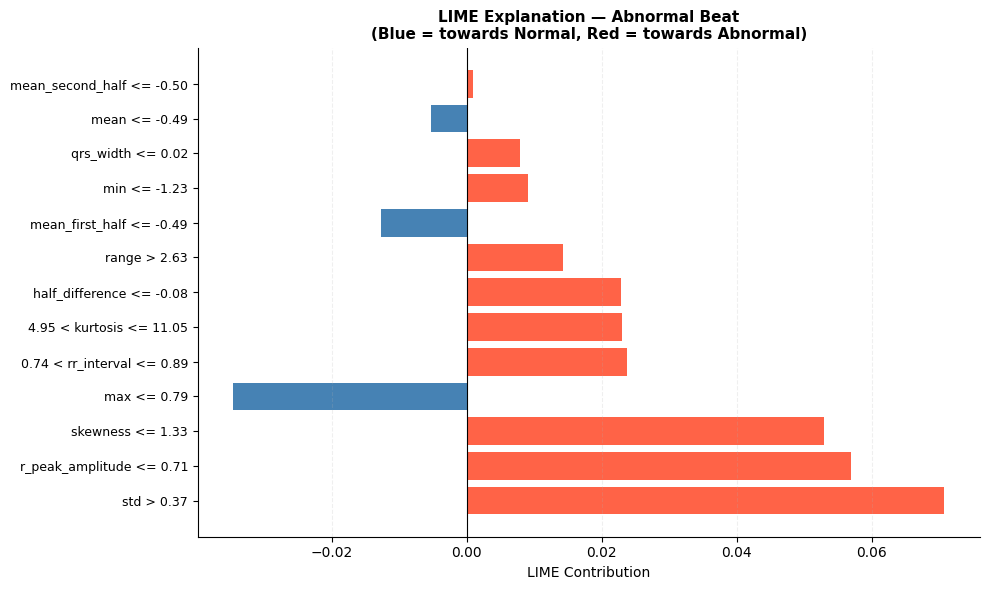

In [19]:
from lime import lime_tabular

# Create LIME explainer
# Training data is needed so LIME understands feature distributions
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Normal', 'Abnormal'],
    mode='classification'
)

print("LIME explainer created")

# LIME explanation for Normal beat 
print("\nGenerating LIME explanation for Normal beat:")

normal_beat_values = X_test_sample.iloc[correct_normal_idx].values

lime_normal = lime_explainer.explain_instance(
    data_row=normal_beat_values,
    predict_fn=rf_model.predict_proba,
    num_features=13,
    num_samples=500
)

# Get feature contributions
normal_contributions = lime_normal.as_list()
print(f"\nLIME explanation — Normal beat:")
print(f"Predicted class: Normal")
print(f"{'Feature condition':<35} {'Contribution':>12}")
print("─" * 50)
for feat, contrib in sorted(normal_contributions,
                             key=lambda x: abs(x[1]),
                             reverse=True):
    direction = "→ Normal" if contrib < 0 else "→ Abnormal"
    print(f"{feat:<35} {contrib:>10.4f}  {direction}")

# Plot LIME explanation for Normal beat
fig, ax = plt.subplots(figsize=(10, 6))
features = [x[0] for x in sorted(normal_contributions,
            key=lambda x: abs(x[1]), reverse=True)]
values = [x[1] for x in sorted(normal_contributions,
          key=lambda x: abs(x[1]), reverse=True)]
colors = ['steelblue' if v < 0 else 'tomato' for v in values]

ax.barh(range(len(features)), values, color=colors)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('LIME Explanation — Normal Beat\n(Blue = towards Normal, Red = towards Abnormal)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('LIME Contribution', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--', axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# LIME explanation for Abnormal beat 
print("\nGenerating LIME explanation for Abnormal beat:")

abnormal_beat_values = X_test_sample.iloc[correct_abnormal_idx].values

lime_abnormal = lime_explainer.explain_instance(
    data_row=abnormal_beat_values,
    predict_fn=rf_model.predict_proba,
    num_features=13,
    num_samples=500
)

# Get feature contributions
abnormal_contributions = lime_abnormal.as_list()
print(f"\nLIME explanation — Abnormal beat:")
print(f"Predicted class: Abnormal")
print(f"{'Feature condition':<35} {'Contribution':>12}")
print("─" * 50)
for feat, contrib in sorted(abnormal_contributions,
                             key=lambda x: abs(x[1]),
                             reverse=True):
    direction = "→ Normal" if contrib < 0 else "→ Abnormal"
    print(f"{feat:<35} {contrib:>10.4f}  {direction}")

# Plot LIME explanation for Abnormal beat
fig, ax = plt.subplots(figsize=(10, 6))
features = [x[0] for x in sorted(abnormal_contributions,
            key=lambda x: abs(x[1]), reverse=True)]
values = [x[1] for x in sorted(abnormal_contributions,
          key=lambda x: abs(x[1]), reverse=True)]
colors = ['steelblue' if v < 0 else 'tomato' for v in values]

ax.barh(range(len(features)), values, color=colors)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('LIME Explanation — Abnormal Beat\n(Blue = towards Normal, Red = towards Abnormal)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('LIME Contribution', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--', axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()